# Part E – Tree-Based Regression Models

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("dataset.csv")

# Convert date
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['sale_year'] = df['sale_date'].dt.year

# Drop unnecessary columns
df.drop(['property_id', 'sale_date'], axis=1, inplace=True)

# Features and Target
X = df.drop('house_price_inr', axis=1)
y = df['house_price_inr']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3040, 10)
(760, 10)


In [8]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Model
dt_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=10,
    random_state=42
)

# Training
dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

# Evaluation
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("R2 Score:", r2_score(y_test, dt_pred))

RMSE: 2834035.525715932
MAE: 2070443.0433378094
R2 Score: 0.900270187184621


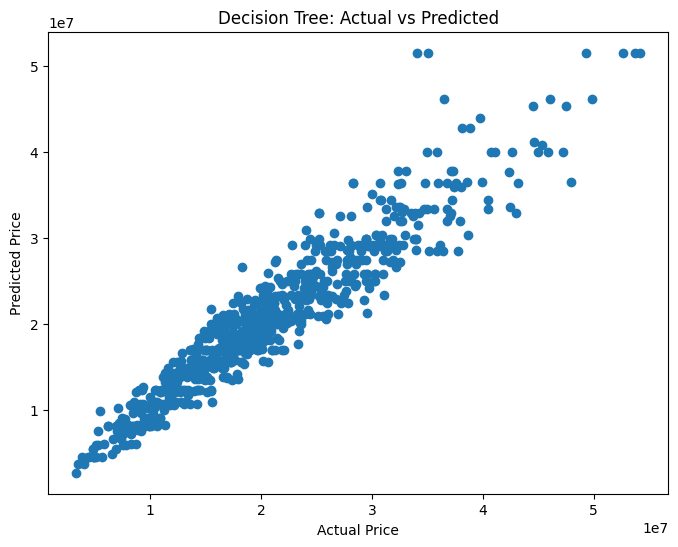

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, dt_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

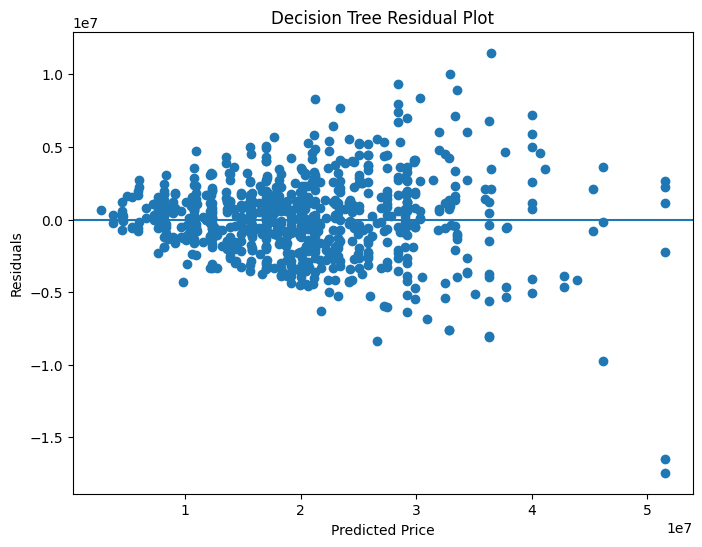

In [11]:
residuals = y_test - dt_pred

plt.figure(figsize=(8,6))
plt.scatter(dt_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Decision Tree Residual Plot")
plt.show()

In [12]:
from sklearn.ensemble import RandomForestRegressor

# Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# Training
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Evaluation
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

RMSE: 2391722.9293761505
MAE: 1750669.8617832249
R2 Score: 0.9289709251320855


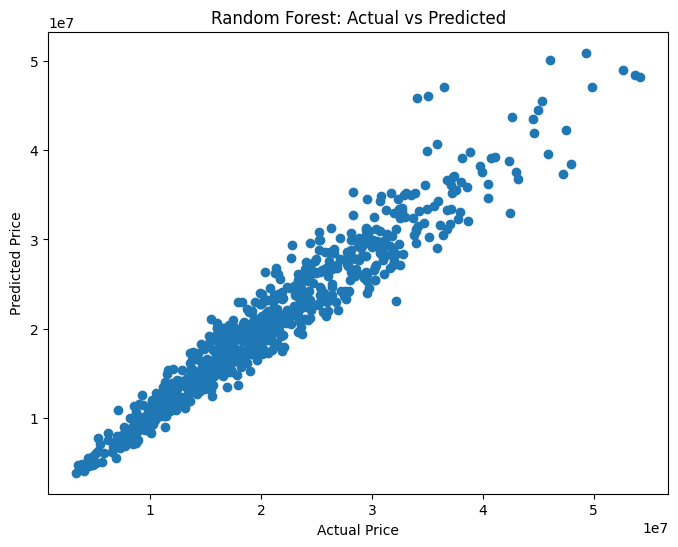

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

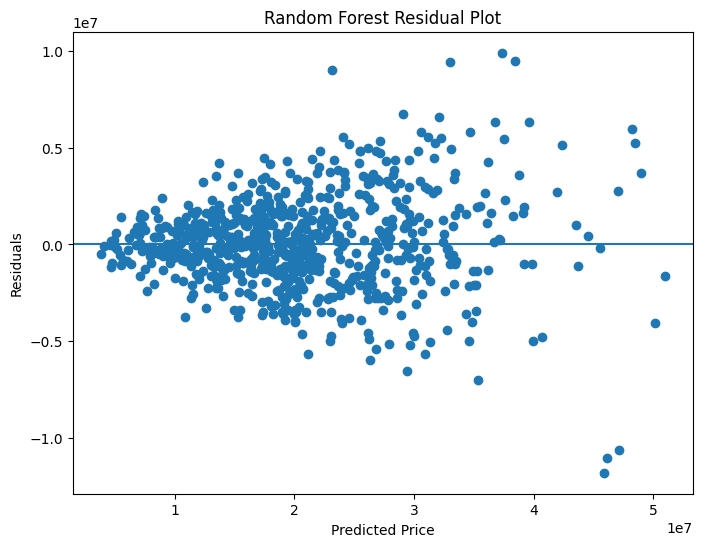

In [14]:
rf_residuals = y_test - rf_pred

plt.figure(figsize=(8,6))
plt.scatter(rf_pred, rf_residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")
plt.show()

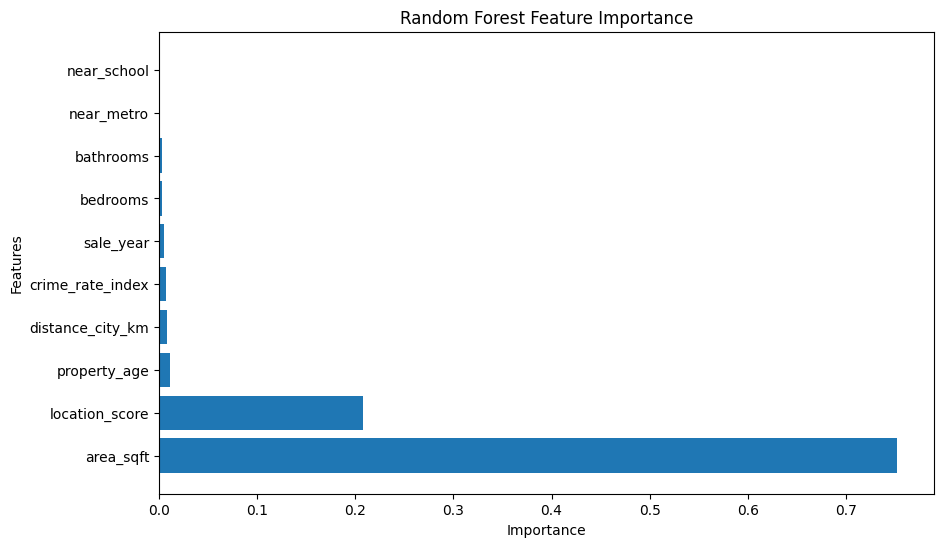

In [15]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

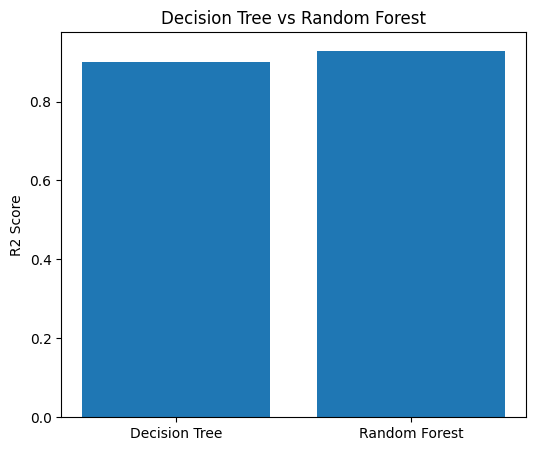

In [16]:
comparison = pd.DataFrame({
    'Model':['Decision Tree','Random Forest'],
    'R2 Score':[
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

plt.figure(figsize=(6,5))
plt.bar(
    comparison['Model'],
    comparison['R2 Score']
)
plt.title("Decision Tree vs Random Forest")
plt.ylabel("R2 Score")
plt.show()

In [19]:
dt_cv = cross_validate(
    dt,
    X_train,
    y_train,
    cv=kf_5,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate, KFold
import numpy as np

kf_5 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

depths = range(1, 16)

dt_train_errors = []
dt_val_errors = []

for depth in depths:

    dt = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    dt_cv = cross_validate(
        dt,
        X_train,      # use X_train
        y_train,
        cv=kf_5,
        scoring='neg_mean_squared_error',
        return_train_score=True
    )

    dt_train_errors.append(
        -np.mean(dt_cv['train_score'])
    )

    dt_val_errors.append(
        -np.mean(dt_cv['test_score'])
    )

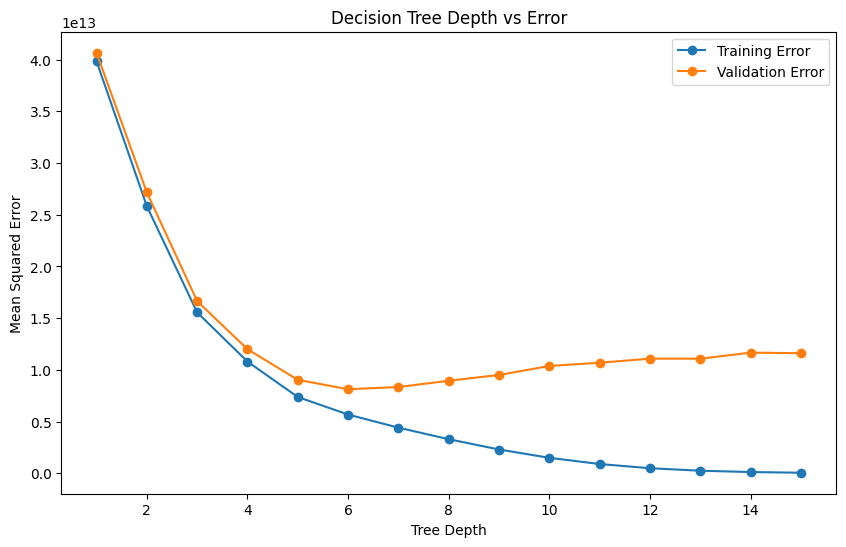

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    depths,
    dt_train_errors,
    marker='o',
    label='Training Error'
)

plt.plot(
    depths,
    dt_val_errors,
    marker='o',
    label='Validation Error'
)

plt.xlabel("Tree Depth")
plt.ylabel("Mean Squared Error")
plt.title("Decision Tree Depth vs Error")

plt.legend()

plt.show()

# Interpretation

## Decision Tree

Easy to understand
Can overfit
Less stable

## Random Forest

Higher accuracy
Lower variance
Better generalization
Usually achieves better R²

---- 

 # *Conclusion (Part E)*

Built a Decision Tree Regressor and evaluated its performance.

Controlled overfitting using max_depth and min_samples_split.

Built a Random Forest Regressor with 100 trees.

Compared both models using RMSE, MAE, and R² Score.

Analyzed feature importance.

Random Forest generally performs better because it combines multiple trees and reduces overfitting.

For your house-price dataset, Random Forest Regressor is expected to outperform Decision Tree Regressor and become one of the strongest models in the project.